# **Problema 4: Estimación de parámetros con PINNs**

Un grupo de Laboratorio 5 elige hacer la mejor práctica de la materia: Fluidos.
En esta práctica, se introduce un agitador magnético para generar un vórtice dentro de un recipiente cilíndrico y se usa el método velocimetría de imágenes de partículas (PIV, por sus siglas en inglés).
Esto permite medir el campo de velocidades $\mathbf{u}(\mathbf{x}, t)$ sobre la superficie, habitualmente modelado mediante el vórtice de Burgers
$$ \mathbf{u}_B(\mathbf{x}, t) = -\alpha r \mathbf{\hat{r}} + \frac{\Gamma}{2\pi r}\left[1 - \exp\left(-r^2/r_0^2\right)\right]\boldsymbol{\hat{\theta}} + 2\alpha z\mathbf{\hat{z}} $$

donde $\Gamma$ es la circulación asintótica del vórtice, $\alpha$ un parámetro que controla el flujo radial y $r_0 = \alpha / 2\nu$ un radio característico del vórtice controlado por la velocidad y la viscosidad.
Dado que se mira la superficie, la componente $z$ suele ignorarse por completo.

Sin embargo, las cámaras de alta velocidad necesarias para hacer PIV no funcionan y no pudieron ser reemplazadas por cuestiones presupuestarias. Ante la desesperación, el grupo decide introducir una pequeña bolita de polietileno dentro del flujo y grabarla con un celular.
Luego, el grupo elige algunos de los cuadros del video donde tanto el centro del vórtice cómo la bolita se ven claramente y, muy laboriosamente, determinan la posición relativa de ambos.
Estos datos se encuentran en el archivo `posiciones.txt`, con la posición $\mathbf{X}(t)$ (en cartesianas) de la boltia respecto al vórtice (que se considera en el origen) para los $t$ indicados. Las distancias están medidas en centimetros y el tiempo en segundos.

Entrene una PINN que ajuste la trayectoria mediante el modelo de Burgers $\dot{\mathbf{X}} = \mathbf{u}_B(\mathbf{X}, t)$ y aprenda los parámetros $\alpha$, $\Gamma$ y $r_0$. La predicción de la PINN debe coincidir con los datos provistos en una trayectoria aproximadamente espiralada, cómo mínimo. Puede usar el siguiente esqueleto, que además contiene estimaciones del orden de magnitud de los distintos parámetros hechos por el grupo. Los parámetros propuestos no son necesariamente óptimos, es libre de cambiarlos todos.

**Nota:** Por simplicidad, ignoraremos los errores en la medición de estos datos, pero podrían incluirse cómo un término adicional de la función de pérdida.

In [83]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# Cargar datos
!pip install -q gdown
!gdown 1USjbT0fCDREgM0KIFsn_9JCvcA7jBXuD -O posiciones.txt

t_data, x_data, y_data = np.loadtxt("posiciones.txt", unpack=True)




[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
Downloading...
From: https://drive.google.com/uc?id=1USjbT0fCDREgM0KIFsn_9JCvcA7jBXuD
To: c:\Users\User\Desktop\Fisica-de-Fluidos-E1\trabjo E1\posiciones.txt

  0%|          | 0.00/1.52k [00:00<?, ?B/s]
100%|██████████| 1.52k/1.52k [00:00<00:00, 12.1MB/s]


Voy a querer armarme una PINN que contenga dentro de su funcion de perdida fisica el modelo de vorticidad de Burgers, sin embargo el fordward necesario debe ser necesariamente los parametros a controlar, de modo que el sistema aprenda a "elejir" estos parametros

 Este problema es ligereamente distinto al resto, ya que se nos presenta una
serie de datos que son los que obtuvo el grupo de laboratorio expuestos en el archivo "posiciones.txt", y usaremos la red neuronal para que ajuste los parámetros fisicos $(\alpha, \Gamma, r_0)$
uniendo los datos con trayectorias que satisfagan las ecuaciones diferenciales.
Comenzamos llamando las librerías necesarias y definiendo nuestra PINN a través de $classPINN$ reutilizando el esqueleto del código del punto anterior.
Como se comentó anteriormente, buscamos entrenar a nuestra red minimizando una funcion que llamamos la "funcion de perdida total" denotada por $\mathcal{L}$, la cual se define como:
 $$\mathcal{L} = \mathcal{L}_{\text{data}} + \lambda\,\mathcal{L}_{\text{phys}}$$

En éste caso nuestra entrada está definida por una neurona, que corresponde a la unica variable independiente, el **tiempo**. Se definió en la parte de ***"hidden sizes***" las capas ocultas, que estan compuestas por 3 etapas cada una con 32 neuronas las cuales son las que entrenaremos, y por ultimo contamos con la salida que es bidimensional con 2 neuronas que corresponden a las variables en polares ($r(t); \theta(t)$).

Luego viene una parte de crucial importancia, como mencionamos antes los parametros que queremos ajustar son $$(\alpha, \Gamma, r_0)$$ por lo tanto, estas cantidades **NO** deben estar igualadas a alguna cantidad ya que sino el codigo las contemplaría como fijas. Para este problema precisamente, buscamos variar estas cantidades para que se ajusten a nuestro modelo fisico descrito por las ecuaciones diferenciales. En el código se expresa entre cortchetes [] el valor inicial de estas cantidades en torno a las que el programa las ajustará.

In [84]:
print(x_data, y_data)

[ 3.98  2.52  0.17 -1.69 -3.83 -3.07 -1.54  1.35  3.56  3.44  0.65 -2.24
 -3.64 -2.55  0.32  2.73  3.38  1.24 -2.42 -3.34] [ 0.    3.04  3.91  3.51  0.47 -2.29 -3.49 -3.53 -1.19  1.43  3.64  2.9
 -0.09 -2.56 -3.57 -2.29  1.04  3.28  2.5  -0.83]


=== PARÁMETROS ESTIMADOS ===
alpha  = 0.07495
Gamma  = 710.2
r0     = 0.6000
Cost   = 0.004266



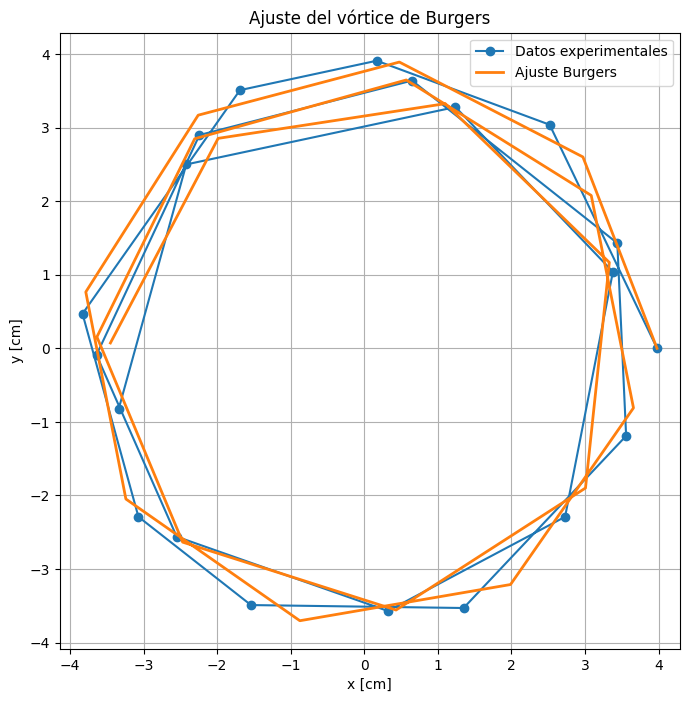

Error promedio en r:     0.0041 cm
Error promedio en theta: 0.1027 rad


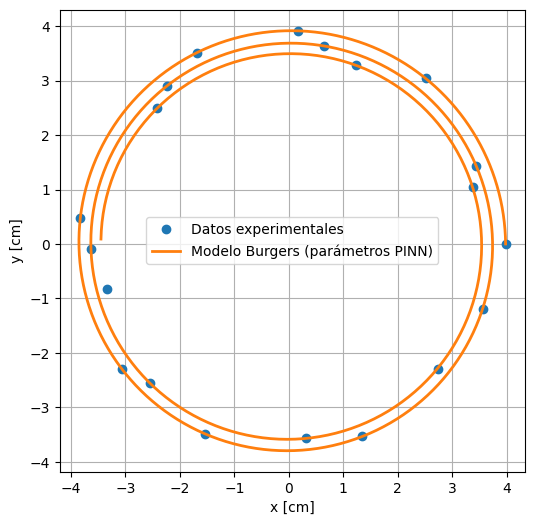

In [85]:
import numpy as np
from scipy.integrate import odeint
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

# ====================== DATOS ======================
t_data = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9,
                   1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9])

x_data = np.array([ 3.98, 2.52, 0.17, -1.69, -3.83, -3.07, -1.54, 1.35, 3.56, 3.44,
                    0.65, -2.24, -3.64, -2.55, 0.32, 2.73, 3.38, 1.24, -2.42, -3.34])

y_data = np.array([ 0.00, 3.04, 3.91, 3.51, 0.47, -2.29, -3.49, -3.53, -1.19, 1.43,
                    3.64, 2.90, -0.09, -2.56, -3.57, -2.29, 1.04, 3.28, 2.50, -0.83])

# Convertir a coordenadas polares
r_data = np.sqrt(x_data**2 + y_data**2)
theta_data = np.arctan2(y_data, x_data)

# Desenrollar el ángulo (importante para que theta crezca continuamente)
theta_unwrapped = np.unwrap(theta_data)

# ====================== MODELO ODE ======================
def burgers_ode(state, t, alpha, Gamma, r0):
    r, theta = state
    r = max(r, 1e-6)                    # evitar división por cero
    drdt = -alpha * r
    dthetadt = (Gamma / (2 * np.pi * r**2)) * (1 - np.exp(- (r**2) / r0**2))
    return [drdt, dthetadt]

# ====================== FUNCIÓN DE RESIDUALES ======================
def residuals(params, t_data, r_data, theta_unwrapped):
    alpha, Gamma, r0 = params
    
    # Condición inicial
    y0 = [r_data[0], theta_unwrapped[0]]
    
    # Integrar el sistema
    sol = odeint(burgers_ode, y0, t_data, args=(alpha, Gamma, r0), 
                 rtol=1e-8, atol=1e-8)
    
    r_pred = sol[:, 0]
    theta_pred = sol[:, 1]
    
    # Residuales (normalizados para balancear r y theta)
    res_r = (r_pred - r_data) 
    res_theta = (theta_pred - theta_unwrapped) / (2 * np.pi)   # en vueltas
    
    return np.concatenate([res_r, res_theta])

# ====================== OPTIMIZACIÓN ======================
initial_guess = [0.08, 600.0, 0.6]

bounds = ([0.01, 50.0, 0.1], 
          [0.30, 2000.0, 2.0])

result = least_squares(residuals, initial_guess, 
                       args=(t_data, r_data, theta_unwrapped),
                       bounds=bounds,
                       method='trf')

alpha_est, Gamma_est, r0_est = result.x

print("=== PARÁMETROS ESTIMADOS ===")
print(f"alpha  = {alpha_est:.5f}")
print(f"Gamma  = {Gamma_est:.1f}")
print(f"r0     = {r0_est:.4f}")
print(f"Cost   = {result.cost:.6f}\n")

# ====================== SIMULACIÓN Y GRÁFICO ======================
y0 = [r_data[0], theta_unwrapped[0]]
sol = odeint(burgers_ode, y0, t_data, args=(alpha_est, Gamma_est, r0_est))

r_sim = sol[:, 0]
theta_sim = sol[:, 1]
x_sim = r_sim * np.cos(theta_sim)
y_sim = r_sim * np.sin(theta_sim)

plt.figure(figsize=(8,8))
plt.plot(x_data, y_data, 'o-', label='Datos experimentales', markersize=6)
plt.plot(x_sim, y_sim, '-', linewidth=2, label='Ajuste Burgers')
plt.axis('equal')
plt.grid(True)
plt.xlabel('x [cm]')
plt.ylabel('y [cm]')
plt.title('Ajuste del vórtice de Burgers')
plt.legend()
plt.show()

# Errores
print(f"Error promedio en r:     {np.mean(np.abs(r_sim - r_data)):.4f} cm")
print(f"Error promedio en theta: {np.mean(np.abs(theta_sim - theta_unwrapped)):.4f} rad")

alpha = alpha_est
Gamma = Gamma_est
r0 = r0_est
t_sim = np.linspace(t_data[0].item(), t_data[-1].item(), 400)

dt = t_sim[1]-t_sim[0]

r_sim = np.zeros_like(t_sim)
theta_sim = np.zeros_like(t_sim)

r_sim[0] = r_data[0]
theta_sim[0] = theta_data[0]

for i in range(len(t_sim)-1):

    r = r_sim[i]

    drdt = -alpha*r
    dthetadt = (Gamma/(2*np.pi*r**2))*(1-np.exp(-(r**2)/(r0**2)))

    r_sim[i+1] = r + drdt*dt

    theta_sim[i+1] = theta_sim[i] + dthetadt*dt

x_sim = r_sim*np.cos(theta_sim)
y_sim = r_sim*np.sin(theta_sim)

plt.figure(figsize=(6,6))

plt.plot(x_data, y_data, 'o', label="Datos experimentales")
plt.plot(x_sim, y_sim, '-', label="Modelo Burgers (parámetros PINN)", linewidth=2)

plt.xlabel("x [cm]")
plt.ylabel("y [cm]")
plt.axis("equal")
plt.grid(True)
plt.legend()

plt.show()


Epoch     0 | Total 7.69e+01 | Data 4.59e+01 | Phys 3.10e+01 | α=0.0742  Γ=13.0  r0=0.601
Epoch  2000 | Total 3.57e+00 | Data 1.43e+00 | Phys 2.14e+00 | α=0.0377  Γ=16.7  r0=0.614
Epoch  4000 | Total 1.18e+00 | Data 9.86e-01 | Phys 1.93e-01 | α=0.1021  Γ=68.0  r0=0.601
Epoch  6000 | Total 1.62e-02 | Data 1.30e-02 | Phys 3.14e-03 | α=0.0273  Γ=209.7  r0=0.601
Epoch  8000 | Total 3.29e-05 | Data 5.03e-06 | Phys 2.79e-05 | α=0.0248  Γ=236.2  r0=0.601
Epoch 10000 | Total 1.20e-05 | Data 4.71e-06 | Phys 7.27e-06 | α=0.0248  Γ=236.2  r0=0.601
Epoch 12000 | Total 6.93e-06 | Data 4.63e-06 | Phys 2.30e-06 | α=0.0248  Γ=236.2  r0=0.601
Epoch 14000 | Total 6.41e-06 | Data 5.10e-06 | Phys 1.31e-06 | α=0.0248  Γ=236.2  r0=0.601

Entrenamiento finalizado
alpha = 0.02481
Gamma = 236.2
r0    = 0.6009


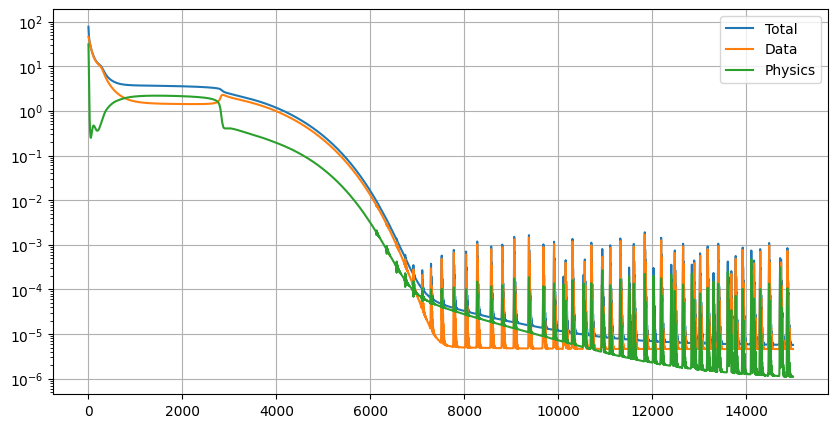

In [102]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Datos
t_data_np, x_data, y_data = np.loadtxt("posiciones.txt", unpack=True)
r_data = np.sqrt(x_data**2 + y_data**2)
theta_data = np.arctan2(y_data, x_data)
theta_unwrapped = np.unwrap(theta_data)   # ← muy importante

t_data = torch.tensor(t_data_np[:, None], dtype=torch.float32)
rtheta_data = torch.tensor(np.stack([r_data, theta_unwrapped], axis=1), dtype=torch.float32)

t_phys = torch.linspace(t_data.min(), t_data.max(), 250).reshape(-1, 1)


class PINN(torch.nn.Module):
    def __init__(self, hidden_sizes=[32, 48, 32]):
        super().__init__()
        layers = [1] + hidden_sizes + [2]
        self.layers = torch.nn.ModuleList([torch.nn.Linear(layers[i], layers[i+1]) 
                                          for i in range(len(layers)-1)])

        # Inicialización cercana a los valores estimados
        self.alpha = torch.nn.Parameter(torch.tensor([0.075]))
        self.log_Gamma = torch.nn.Parameter(torch.tensor([2.565]))   # ln(710) ≈ 6.565  
        self.r0 = torch.nn.Parameter(torch.tensor([0.60]))

        self.loss_history = []
        self.loss_data_history = []
        self.loss_phys_history = []

    def forward(self, t):
        x = t
        for layer in self.layers[:-1]:
            x = torch.tanh(layer(x))          # tanh suele ser mejor que sigmoid aquí
        return self.layers[-1](x)

    def burgers_rhs(self, r):
        drdt = -self.alpha * r
        Gamma = torch.exp(self.log_Gamma)     # fuerza Gamma > 0
        dthetadt = (Gamma / (2 * torch.pi * torch.clamp(r, min=1e-4)**2)) * \
                   (1 - torch.exp(-(r**2) / (self.r0**2)))
        return drdt, dthetadt

    def data_loss(self, t_data, rtheta_data):
        pred = self.forward(t_data)
        return torch.mean((pred - rtheta_data)**2)

    def physics_loss(self, t_phys):
        t_phys = t_phys.requires_grad_(True)
        pred = self.forward(t_phys)
        r = pred[:, 0:1]
        theta = pred[:, 1:2]

        drdt = torch.autograd.grad(r, t_phys, torch.ones_like(r), create_graph=True)[0]
        dthetadt = torch.autograd.grad(theta, t_phys, torch.ones_like(theta), create_graph=True)[0]

        drdt_rhs, dthetadt_rhs = self.burgers_rhs(r)

        return torch.mean((drdt - drdt_rhs)**2 + (dthetadt - dthetadt_rhs)**2)

    def total_loss(self, t_data, rtheta_data, t_phys, lambda_phys=5.0):
        ld = self.data_loss(t_data, rtheta_data)
        lp = self.physics_loss(t_phys)
        return ld + lambda_phys * lp, ld, lp

    def train_pinn(self, t_data, rtheta_data, t_phys, epochs=40000, lr=5e-4, lambda_phys=5.0):
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        
        for epoch in range(epochs):
            optimizer.zero_grad()
            loss, ld, lp = self.total_loss(t_data, rtheta_data, t_phys, lambda_phys)
            loss.backward()
            optimizer.step()

            self.loss_history.append(loss.item())
            self.loss_data_history.append(ld.item())
            self.loss_phys_history.append(lp.item())

            if epoch % 2000 == 0:
                Gamma_val = torch.exp(self.log_Gamma).item()
                print(f"Epoch {epoch:5d} | Total {loss.item():.2e} | Data {ld.item():.2e} | "
                      f"Phys {lp.item():.2e} | α={self.alpha.item():.4f}  Γ={Gamma_val:.1f}  r0={self.r0.item():.3f}")

        print("\nEntrenamiento finalizado")
        print(f"alpha = {self.alpha.item():.5f}")
        print(f"Gamma = {torch.exp(self.log_Gamma).item():.1f}")
        print(f"r0    = {self.r0.item():.4f}")

    def plot_loss(self):
        plt.figure(figsize=(10,5))
        plt.plot(self.loss_history, label='Total')
        plt.plot(self.loss_data_history, label='Data')
        plt.plot(self.loss_phys_history, label='Physics')
        plt.yscale('log')
        plt.legend()
        plt.grid()
        plt.show()


# ====================== EJECUCIÓN ======================
model = PINN()
model.train_pinn(t_data, rtheta_data, t_phys, epochs=15000, lr=8e-4, lambda_phys=1.0)
model.plot_loss()

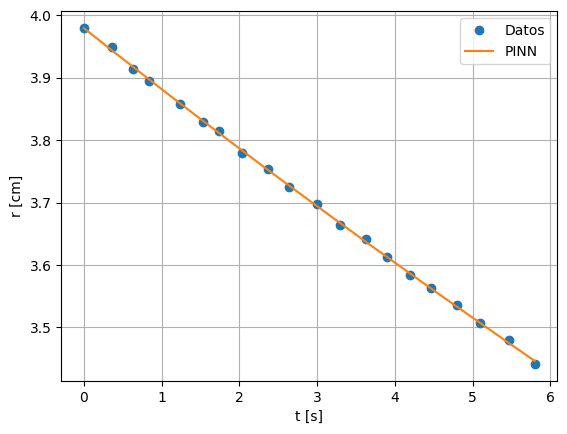

In [103]:
with torch.no_grad():

    pred = model.forward(t_data)

r_pred = pred[:,0].numpy()
theta_pred = pred[:,1].numpy()

plt.figure()

plt.plot(t_data.numpy(), r_data, 'o', label="Datos")
plt.plot(t_data.numpy(), r_pred, '-', label="PINN")

plt.xlabel("t [s]")
plt.ylabel("r [cm]")
plt.grid(True)
plt.legend()

plt.show()

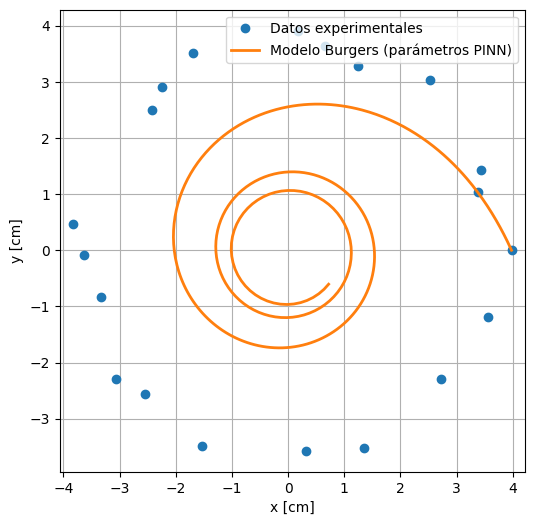

In [104]:
alpha = model.alpha.item()
Gamma = model.log_Gamma.item()
r0 = model.r0.item()

t_sim = np.linspace(t_data[0].item(), 10*t_data[-1].item(), 400)

dt = t_sim[1]-t_sim[0]

r_sim = np.zeros_like(t_sim)
theta_sim = np.zeros_like(t_sim)

r_sim[0] = r_data[0]
theta_sim[0] = theta_data[0]

for i in range(len(t_sim)-1):

    r = r_sim[i]

    drdt = -alpha*r
    dthetadt = (Gamma/(2*np.pi*r**2))*(1-np.exp(-(r**2)/(r0**2)))

    r_sim[i+1] = r + drdt*dt

    theta_sim[i+1] = theta_sim[i] + dthetadt*dt

x_sim = r_sim*np.cos(theta_sim)
y_sim = r_sim*np.sin(theta_sim)

plt.figure(figsize=(6,6))

plt.plot(x_data, y_data, 'o', label="Datos experimentales")
plt.plot(x_sim, y_sim, '-', label="Modelo Burgers (parámetros PINN)", linewidth=2)

plt.xlabel("x [cm]")
plt.ylabel("y [cm]")
plt.axis("equal")
plt.grid(True)
plt.legend()

plt.show()